이번 미션에서는  모델을 활용하여 FashionMNIST 데이터셋의 각 패션 아이템(예: 티셔츠, 바지, 스니커즈 등)을 조건부로 생성하는 작업을 수행합니다. 

각 클래스에 해당하는 이미지를 생성하는 cGAN (Conditional GAN) 모델을 직접 설계하고 학습시켜 보세요.

### 기본 설정

In [7]:
import gc
import torch

# config 클래스 생성
class Config:
    # 디바이스 설정
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        DEVICE = torch.device("mps") # 맥 GPU
    elif torch.cuda.is_available():
        DEVICE = torch.device("cuda:0") # 윈도우 GPU
    else:
        DEVICE = torch.device("cpu") # CPU

    # 캐시 지우기 함수 생성
    @staticmethod
    def clean_cache():
        gc.collect()
        if Config.DEVICE.type == "mps":
            torch.mps.empty_cache()
        elif Config.DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    LOG_LEVEL = "INFO"

In [8]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


# 로그
import logging

def init_logger() -> logging.Logger:
    logging.basicConfig(
        format="%(asctime)s [%(levelname)s] (%(filename)s:%(lineno)d) - %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
        level=logging.INFO,
        encoding="utf-8",
    )
    return logging.getLogger("")

logger = init_logger()

2025-12-05 00:50:40 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/Supplemental/NISC18030.ttf: Could not set the fontsize (invalid pixel size; error code 0x17)
2025-12-05 00:50:40 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/Apple Color Emoji.ttc: Could not set the fontsize (invalid pixel size; error code 0x17)
2025-12-05 00:50:40 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/LastResort.otf: tuple indices must be integers or slices, not str
2025-12-05 00:50:40 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/Fonts/SFIndia.ttc: Can not load face (SFNT font table missing; error code 0x8e)
2025-12-05 00:50:40 [INFO] (font_manager.py:1107) - Failed to extract font properties from /System/Library/PrivateFrameworks/FontServices.framework/Resources/Reserved/PingFangUI.ttc: Can not load face (locations (loca) table mi

## 1. 데이터 파악 및 오류 확인

In [3]:
import torchvision

train_dataset = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True)

In [4]:
print(f"[데이터 개수]")
print(f"· 학습 데이터: {len(train_dataset)}개")
print(f"· 테스트 데이터: {len(test_dataset)}개")

print(f"\n[데이터 형식]")
print(f"· 학습 데이터: {train_dataset[0]}")
print(f"· 테스트 데이터: {test_dataset[0]}")

train_size_set = set()
for data in train_dataset:
    train_size_set.add(data[0].size)

test_size_set = set()
for data in test_dataset:
    test_size_set.add(data[0].size)

print(f"\n[사이즈 구성]")
print(f"· 학습 데이터: {train_size_set}")
print(f"· 테스트 데이터: {test_size_set}")

[데이터 개수]
· 학습 데이터: 60000개
· 테스트 데이터: 10000개

[데이터 형식]
· 학습 데이터: (<PIL.Image.Image image mode=L size=28x28 at 0x109D76E90>, 9)
· 테스트 데이터: (<PIL.Image.Image image mode=L size=28x28 at 0x109CBF2E0>, 9)

[사이즈 구성]
· 학습 데이터: {(28, 28)}
· 테스트 데이터: {(28, 28)}


데이터는 흑백의 28*28 사이즈 이미지와 클래스로 구성되어 있다.

In [5]:
TRAIN_CLASS_DICT = {i: class_name for i, class_name in enumerate(train_dataset.classes)}
TEST_CLASS_DICT = {i: class_name for i, class_name in enumerate(test_dataset.classes)}

print(f"[클래스 형식]")
print(f"· 학습 데이터: {TRAIN_CLASS_DICT}")
print(f"· 테스트 데이터: {TEST_CLASS_DICT}")

print(f"\n[클래스 개수]")
train_count_list = [0 for _ in range(10)]
test_count_list = [0 for _ in range(10)]

for data in train_dataset:
    label = int(data[1])
    train_count_list[label] += 1

for data in test_dataset:
    label = int(data[1])
    test_count_list[label] += 1

print("· 학습 데이터: ", end="")
for label, label_count in enumerate(train_count_list):
    print(f"{label}: {label_count}개", end=" | ")

print("\n· 테스트 데이터: ", end="")
for label, label_count in enumerate(test_count_list):
    print(f"{label}: {label_count}개", end=" | ")

CLASS_DICT = {i: class_name for i, class_name in enumerate(train_dataset.classes)}

[클래스 형식]
· 학습 데이터: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}
· 테스트 데이터: {0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

[클래스 개수]
· 학습 데이터: 0: 6000개 | 1: 6000개 | 2: 6000개 | 3: 6000개 | 4: 6000개 | 5: 6000개 | 6: 6000개 | 7: 6000개 | 8: 6000개 | 9: 6000개 | 
· 테스트 데이터: 0: 1000개 | 1: 1000개 | 2: 1000개 | 3: 1000개 | 4: 1000개 | 5: 1000개 | 6: 1000개 | 7: 1000개 | 8: 1000개 | 9: 1000개 | 

클래스 균형이 완벽하다.

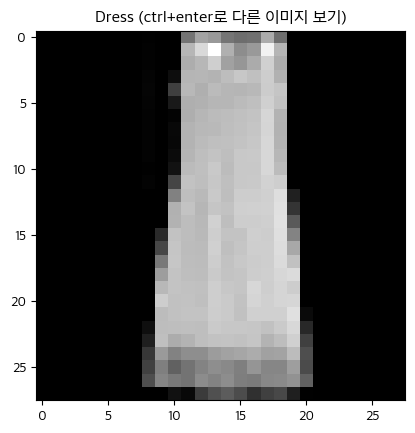

In [6]:
import random

rand_idx = random.randint(0, len(train_dataset))
data = train_dataset[rand_idx]

plt.imshow(data[0], cmap="gray")
plt.title(f"{CLASS_DICT[data[1]]} (ctrl+enter로 다른 이미지 보기)")
plt.show()

## 2. 실험 설계

- 일반적인 cGAN 모델을 이용하여 실험을 진행한다.

In [ ]:
import torchvision.transforms as transforms

TRANSFORM = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))
                                ])

TRAIN_DATASET = torchvision.datasets.FashionMNIST(root="./data", train=True, download=True, transform=TRANSFORM)
TEST_DATASET = torchvision.datasets.FashionMNIST(root="./data", train=False, download=True, transform=TRANSFORM)

TRAIN_LOADER = torch.utils.data.DataLoader(TRAIN_DATASET, batch_size=64, shuffle=True)
TEST_LOADER = torch.utils.data.DataLoader(TEST_DATASET, batch_size=64, shuffle=False)

Epoch [1/30]  D_loss: 0.6323  G_loss: 1.6595  D(x): 0.75  D(G(z)): 0.25
Epoch [2/30]  D_loss: 0.5464  G_loss: 2.0270  D(x): 0.79  D(G(z)): 0.21
Epoch [3/30]  D_loss: 0.8313  G_loss: 1.5149  D(x): 0.70  D(G(z)): 0.30
Epoch [4/30]  D_loss: 0.9605  G_loss: 1.2911  D(x): 0.66  D(G(z)): 0.34
Epoch [5/30]  D_loss: 1.0108  G_loss: 1.2299  D(x): 0.64  D(G(z)): 0.36
Epoch [6/30]  D_loss: 1.0309  G_loss: 1.2141  D(x): 0.63  D(G(z)): 0.37
Epoch [7/30]  D_loss: 1.0346  G_loss: 1.2098  D(x): 0.63  D(G(z)): 0.37
Epoch [8/30]  D_loss: 1.0238  G_loss: 1.2314  D(x): 0.64  D(G(z)): 0.36
Epoch [9/30]  D_loss: 1.0187  G_loss: 1.2490  D(x): 0.64  D(G(z)): 0.36
Epoch [10/30]  D_loss: 1.0097  G_loss: 1.2651  D(x): 0.64  D(G(z)): 0.36


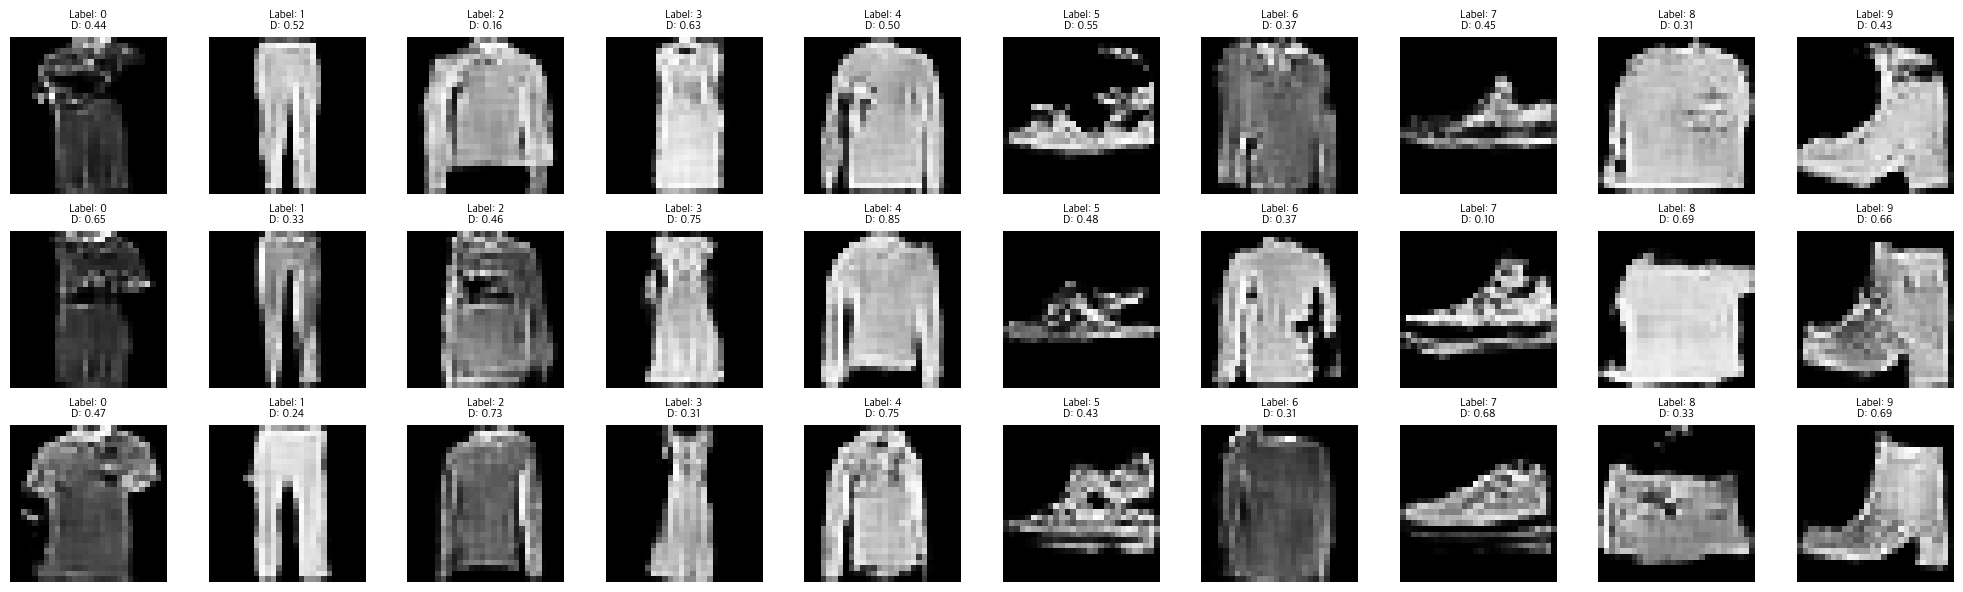

Epoch [11/30]  D_loss: 1.0007  G_loss: 1.2872  D(x): 0.64  D(G(z)): 0.36
Epoch [12/30]  D_loss: 0.9973  G_loss: 1.2984  D(x): 0.65  D(G(z)): 0.35
Epoch [13/30]  D_loss: 0.9975  G_loss: 1.3056  D(x): 0.65  D(G(z)): 0.35
Epoch [14/30]  D_loss: 0.9850  G_loss: 1.3211  D(x): 0.65  D(G(z)): 0.35
Epoch [15/30]  D_loss: 0.9766  G_loss: 1.3392  D(x): 0.65  D(G(z)): 0.35
Epoch [16/30]  D_loss: 0.9694  G_loss: 1.3641  D(x): 0.66  D(G(z)): 0.34
Epoch [17/30]  D_loss: 0.9621  G_loss: 1.3764  D(x): 0.66  D(G(z)): 0.34
Epoch [18/30]  D_loss: 0.9558  G_loss: 1.3889  D(x): 0.66  D(G(z)): 0.34
Epoch [19/30]  D_loss: 0.9443  G_loss: 1.4178  D(x): 0.67  D(G(z)): 0.33
Epoch [20/30]  D_loss: 0.9387  G_loss: 1.4248  D(x): 0.67  D(G(z)): 0.33


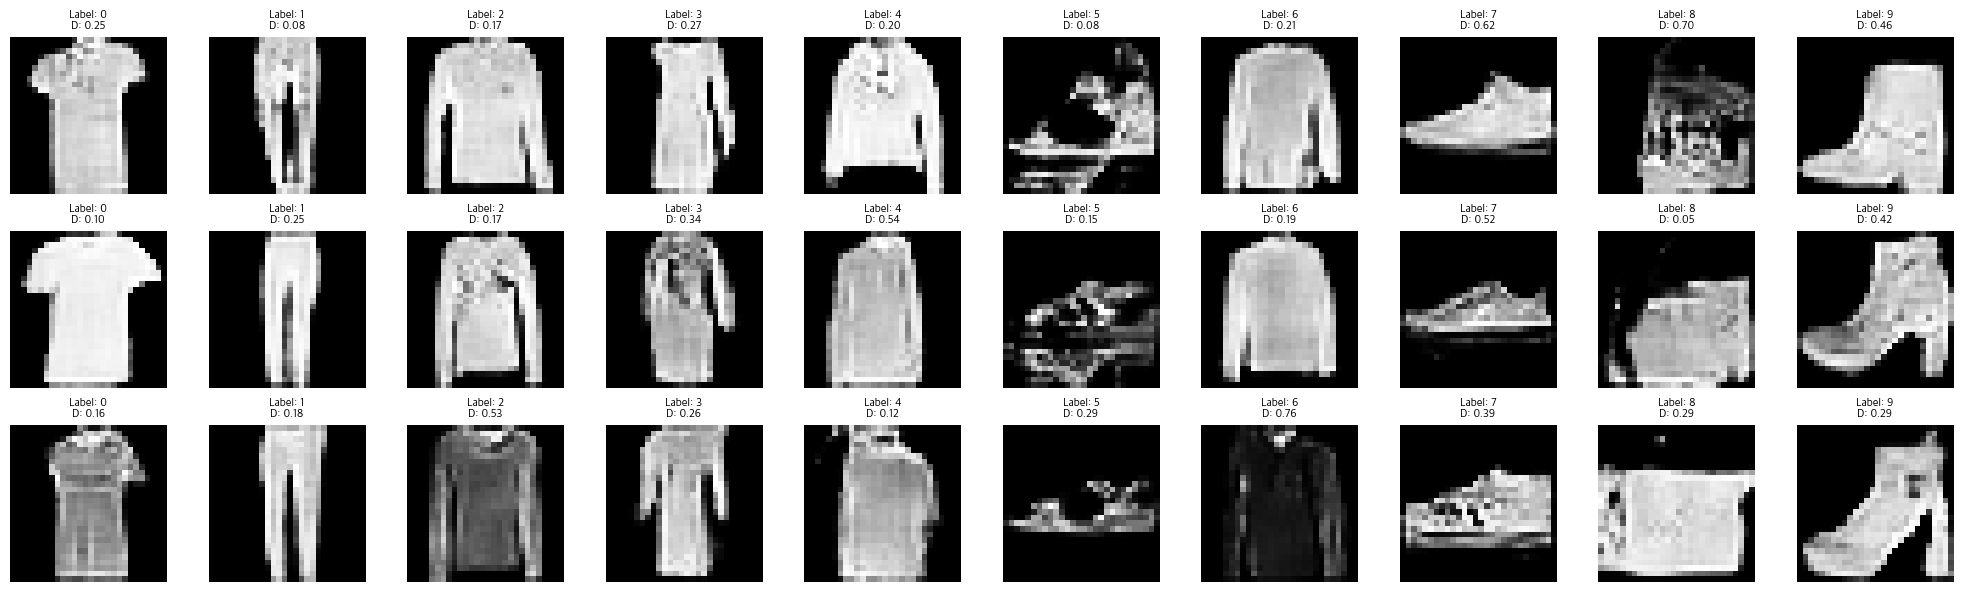

Epoch [21/30]  D_loss: 0.9370  G_loss: 1.4364  D(x): 0.67  D(G(z)): 0.33
Epoch [22/30]  D_loss: 0.9294  G_loss: 1.4523  D(x): 0.67  D(G(z)): 0.33
Epoch [23/30]  D_loss: 0.9290  G_loss: 1.4641  D(x): 0.67  D(G(z)): 0.33
Epoch [24/30]  D_loss: 0.9275  G_loss: 1.4707  D(x): 0.67  D(G(z)): 0.33
Epoch [25/30]  D_loss: 0.9276  G_loss: 1.4714  D(x): 0.67  D(G(z)): 0.33
Epoch [26/30]  D_loss: 0.9261  G_loss: 1.4829  D(x): 0.68  D(G(z)): 0.32
Epoch [27/30]  D_loss: 0.9274  G_loss: 1.4829  D(x): 0.68  D(G(z)): 0.32
Epoch [28/30]  D_loss: 0.9242  G_loss: 1.4936  D(x): 0.68  D(G(z)): 0.32
Epoch [29/30]  D_loss: 0.9146  G_loss: 1.5097  D(x): 0.68  D(G(z)): 0.32
Epoch [30/30]  D_loss: 0.9081  G_loss: 1.5141  D(x): 0.68  D(G(z)): 0.32


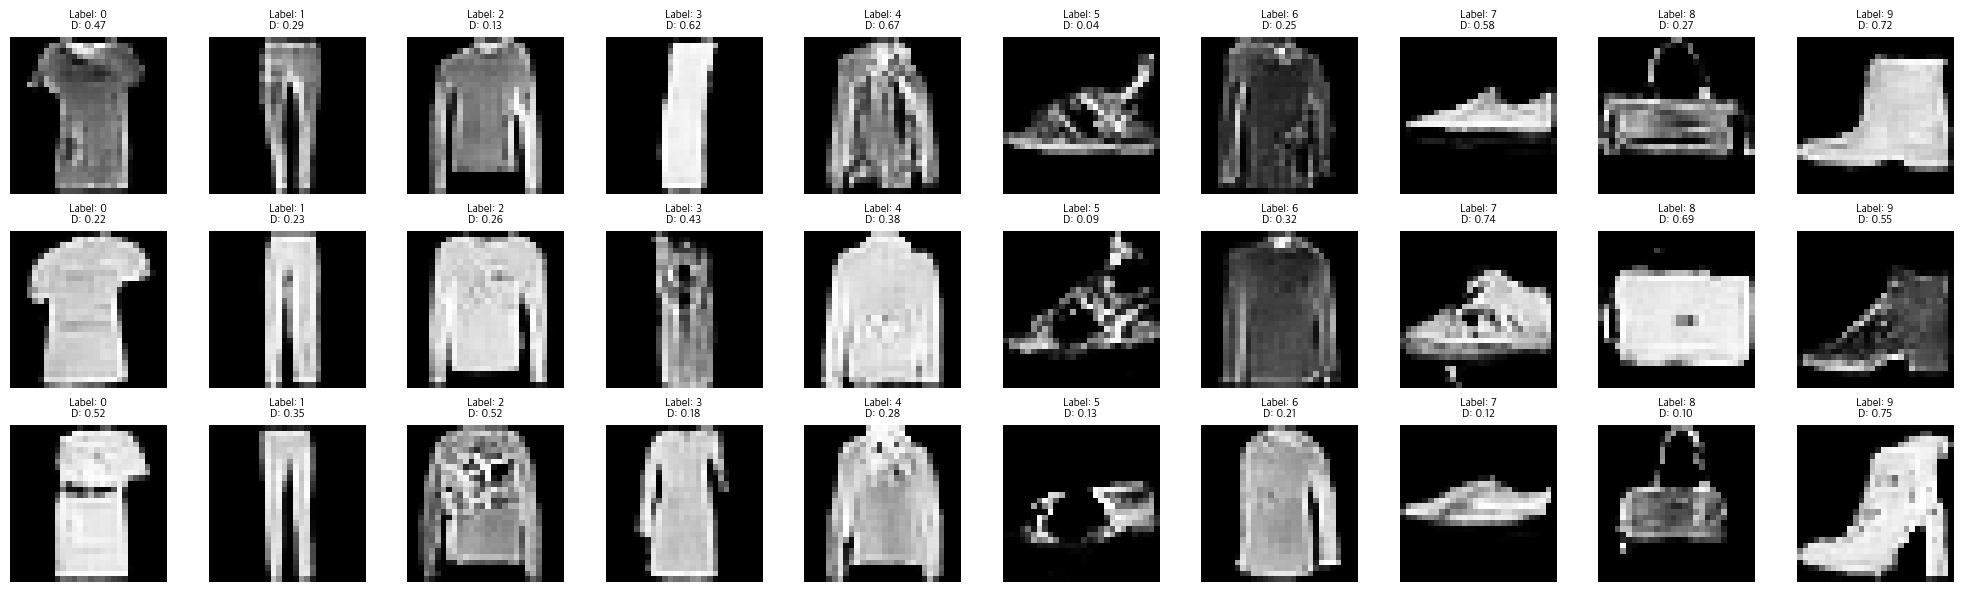

In [ ]:
import torch.nn as nn
import torch.optim as optim

image_size = 28      # MNIST 이미지 크기
num_classes = 10     # 10개 클래스 (0~9)
latent_dim = 100     # 잠재 공간 차원

# 생성자 (Generator)
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # 레이블 임베딩
        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.init_size = image_size // 4  # 7

        self.l1 = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 128 * self.init_size * self.init_size),
            nn.ReLU(inplace=True)
        )

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),  # 7 → 14
            nn.Conv2d(128, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64, 0.8),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2),  # 14 → 28
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),
            nn.Tanh()  # 출력 범위 [-1, 1]
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        gen_input = torch.cat((noise, label_input), -1)
        out = self.l1(gen_input)
        out = out.view(out.size(0), 128, self.init_size, self.init_size)
        img = self.conv_blocks(out)
        return img

# 판별자 (Discriminator)
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        # 레이블을 단일 채널 값으로 임베딩
        self.label_emb = nn.Embedding(num_classes, 1)

        self.model = nn.Sequential(
            # 이미지(1 채널)와 레이블(1 채널)을 채널 차원에서 결합하여 2채널로 입력
            nn.Conv2d(1 + 1, 64, kernel_size=3, stride=2, padding=1),  # 28 → 14
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),      # 14 → 7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Flatten(),
            nn.Linear(128 * (image_size // 4) * (image_size // 4), 1),   # 128*7*7
            nn.Sigmoid()
        )

    def forward(self, img, labels):
        batch_size = img.size(0)
        label = self.label_emb(labels)
        label = label.view(batch_size, 1, 1, 1)
        label = label.expand(batch_size, 1, image_size, image_size)
        # 이미지와 레이블을 채널 차원에서 연결
        d_in = torch.cat((img, label), 1)
        validity = self.model(d_in)
        return validity


# 모델 초기화
generator = Generator().to(Config.DEVICE)
discriminator = Discriminator().to(Config.DEVICE)

epochs = 30
criterion = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

# 학습 루프 (에포크마다 D(x)와 D(G(z)) 평균 점수 계산)
for epoch in range(epochs):
    running_d_loss = 0.0
    running_g_loss = 0.0
    d_x_total = 0.0
    d_gz_total = 0.0
    total_samples = 0

    for i, (imgs, labels) in enumerate(TRAIN_LOADER):
        batch_size_current = imgs.size(0)
        total_samples += batch_size_current
        imgs = imgs.to(Config.DEVICE)
        labels = labels.to(Config.DEVICE)

        valid = torch.ones(batch_size_current, 1, device=Config.DEVICE)
        fake = torch.zeros(batch_size_current, 1, device=Config.DEVICE)

        # 판별자 학습
        optimizer_D.zero_grad()
        # 실제 이미지에 대한 판별자 출력
        real_pred = discriminator(imgs, labels)
        real_loss = criterion(real_pred, valid)
        d_x_total += real_pred.mean().item() * batch_size_current

        noise = torch.randn(batch_size_current, latent_dim, device=Config.DEVICE)
        gen_labels = labels  # (여기서는 입력된 라벨 사용)
        gen_imgs = generator(noise, gen_labels)
        # 가짜 이미지에 대한 판별자 출력
        fake_pred = discriminator(gen_imgs.detach(), labels)
        fake_loss = criterion(fake_pred, fake)
        d_gz_total += fake_pred.mean().item() * batch_size_current

        d_loss = real_loss + fake_loss
        d_loss.backward()
        optimizer_D.step()

        # 생성자 학습
        optimizer_G.zero_grad()
        g_loss = criterion(discriminator(gen_imgs, labels), valid)
        g_loss.backward()
        optimizer_G.step()

        running_d_loss += d_loss.item() * batch_size_current
        running_g_loss += g_loss.item() * batch_size_current

    avg_d_loss = running_d_loss / total_samples
    avg_g_loss = running_g_loss / total_samples
    avg_d_x = d_x_total / total_samples
    avg_d_gz = d_gz_total / total_samples

    print(f"Epoch [{epoch+1}/{epochs}]  D_loss: {avg_d_loss:.4f}  G_loss: {avg_g_loss:.4f}  D(x): {avg_d_x:.2f}  D(G(z)): {avg_d_gz:.2f}")

    # 10 에포크마다 생성 이미지 시각화 (각 클래스별로 3개씩 출력)
    if (epoch + 1) % 10 == 0:
        generator.eval()
        n_row = 3               # 각 클래스당 3개씩
        n_col = num_classes     # 총 10개 클래스
        total_samples_vis = n_row * n_col
        noise = torch.randn(total_samples_vis, latent_dim, device=Config.DEVICE)
        labels_sample = torch.arange(0, num_classes, device=Config.DEVICE).repeat(n_row)
        with torch.no_grad():
            gen_imgs = generator(noise, labels_sample)
            disc_out = discriminator(gen_imgs, labels_sample)
        gen_imgs = gen_imgs.detach().cpu().numpy()
        disc_out = disc_out.detach().cpu().numpy()

        fig, axes = plt.subplots(n_row, n_col, figsize=(n_col * 2, n_row * 2))
        for i in range(n_row):
            for j in range(n_col):
                idx = i * n_col + j
                axes[i, j].imshow(gen_imgs[idx, 0, :, :], cmap='gray')
                axes[i, j].axis('off')
                score = disc_out[idx, 0]
                axes[i, j].set_title(f"Label: {labels_sample[idx].item()}\nD: {score:.2f}", fontsize=8)
        plt.tight_layout()
        plt.show()
        generator.train()


생성된 이미지의 shape: torch.Size([8, 1, 28, 28])
판별자 출력의 shape: torch.Size([8, 1])


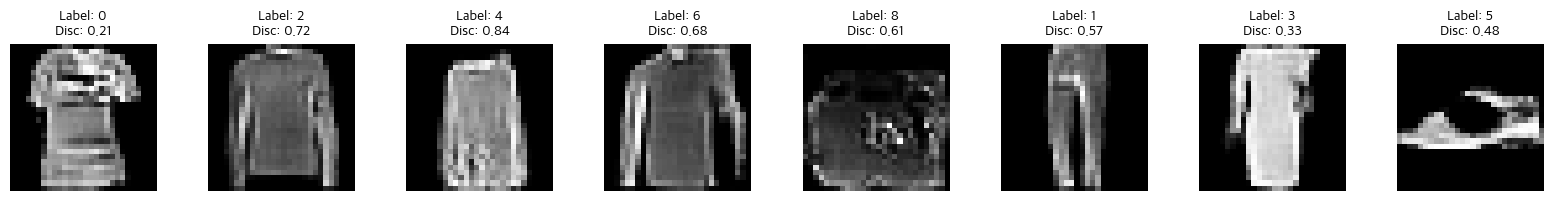

In [ ]:
# generator와 discriminator 작동 확인 및 시각화 (라벨, 판별자 결과 포함)
generator.eval()
discriminator.eval()

# 사용자가 직접 입력한 라벨 (예: [0, 2, 4, 6, 8, 1, 3, 5])
manual_labels = torch.tensor([0, 2, 4, 6, 8, 1, 3, 5], device=Config.DEVICE)
batch_size = manual_labels.size(0)

# 입력 라벨에 맞춰 노이즈 생성
noise = torch.randn(batch_size, latent_dim, device=Config.DEVICE)

# 생성자와 판별자 실행
with torch.no_grad():
    fake_images = generator(noise, manual_labels)
    disc_output = discriminator(fake_images, manual_labels)

print("생성된 이미지의 shape:", fake_images.shape)  # 예상: [batch_size, 1, 28, 28]
print("판별자 출력의 shape:", disc_output.shape)     # 예상: [batch_size, 1]

# 결과 시각화: 생성된 이미지와 라벨, 판별자 결과를 함께 표시
fake_images_cpu = fake_images.detach().cpu().numpy()
disc_output_cpu = disc_output.detach().cpu().numpy()

fig, axes = plt.subplots(1, batch_size, figsize=(batch_size * 2, 2))
for i in range(batch_size):
    axes[i].imshow(fake_images_cpu[i, 0, :, :], cmap='gray')
    axes[i].axis('off')
    score = disc_output_cpu[i, 0]
    axes[i].set_title(f"Label: {manual_labels[i].item()}\nDisc: {score:.2f}", fontsize=10)
plt.tight_layout()
plt.show()